# SomaTrack — Phase 4: Model Development & Training
**Project:** Predicting Study-Related Physical Ailments  
**Input:** `SomaTrack_FS_Ready.csv` — 1,170 samples · 22 features · 7 targets  

Each target is trained as an independent **multiclass classification** problem (0–3).  
Five model families are evaluated, tuned with cross-validated grid search, and compared.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Train / Test Split & Class Imbalance Strategy](#2)
3. [Baseline Models](#3)
4. [Hyperparameter Tuning](#4)
5. [Best Model Selection per Target](#5)
6. [Cross-Validated Performance Summary](#6)
7. [Learning Curves](#7)
8. [Export — Trained Models & Results](#8)


## 1. Setup & Data Loading

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, json, pickle, os
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    RandomizedSearchCV, train_test_split, learning_curve
)
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
import xgboost as xgb
import lightgbm as lgb

# ── GPU detection ─────────────────────────────────────────────────────────────
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    GPU_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else 'N/A'
except ImportError:
    GPU_AVAILABLE = False
    GPU_NAME = 'N/A'

if GPU_AVAILABLE:
    print(f"✓ GPU detected : {GPU_NAME}")
    XGB_DEVICE  = 'cuda'
    LGBM_DEVICE = 'gpu'
else:
    print("⚠ No GPU detected — falling back to CPU (n_jobs=-1)")
    XGB_DEVICE  = 'cpu'
    LGBM_DEVICE = 'cpu'

# ── Visual style ──────────────────────────────────────────────────────────────
PAIN_COLORS   = ['#27ae60','#f39c12','#e67e22','#e74c3c']
TARGET_COLORS = {
    'target_back_pain':'#e74c3c', 'target_neck_strain':'#e67e22',
    'target_headache':'#f39c12',  'target_wrist_pain':'#2ecc71',
    'target_eye_strain':'#3498db','target_finger_numb':'#9b59b6',
    'target_overall':'#1abc9c',
}
TARGET_NICE = {
    'target_back_pain':'Back Pain',       'target_neck_strain':'Neck Strain',
    'target_headache':'Headache',         'target_wrist_pain':'Wrist Pain',
    'target_eye_strain':'Eye Strain',     'target_finger_numb':'Finger Numb.',
    'target_overall':'Overall Discomfort',
}
CLASS_NAMES = ['None','Mild','Moderate','Chronic']
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 11, 'axes.labelsize': 10,
})

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('SomaTrack_FS_Ready.csv')
with open('fs_metadata.json') as f:
    meta = json.load(f)

FEATURE_COLS = meta['selected_features']
TARGET_COLS  = meta['target_cols']
X = df[FEATURE_COLS].copy()

RANDOM_STATE = 42
CV_FOLDS     = 5
TEST_SIZE    = 0.20
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Dataset  : {df.shape}")
print(f"Features : {len(FEATURE_COLS)}")
print(f"Targets  : {len(TARGET_COLS)}")
print(f"\nClass distributions:")
for t in TARGET_COLS:
    vc = df[t].value_counts().sort_index()
    print(f"  {TARGET_NICE[t]:22s}: {vc.to_dict()}")


✓ GPU detected : NVIDIA GeForce RTX 4060 Laptop GPU
Dataset  : (1170, 29)
Features : 22
Targets  : 7

Class distributions:
  Back Pain             : {0: 98, 1: 320, 2: 362, 3: 390}
  Neck Strain           : {0: 166, 1: 382, 2: 378, 3: 244}
  Headache              : {0: 172, 1: 390, 2: 366, 3: 242}
  Wrist Pain            : {0: 445, 1: 375, 2: 235, 3: 115}
  Eye Strain            : {0: 145, 1: 357, 2: 387, 3: 281}
  Finger Numb.          : {0: 393, 1: 434, 2: 230, 3: 113}
  Overall Discomfort    : {0: 85, 1: 675, 2: 377, 3: 33}


## 2. Train / Test Split & Class Imbalance Strategy

We use a **stratified 80/20 split** to preserve class proportions.  
Class imbalance is handled at the **model level** via `class_weight='balanced'`  
(Logistic Regression, SVM, Random Forest, GBM) or `scale_pos_weight` / `is_unbalance`  
(XGBoost, LightGBM) — avoiding data leakage from over/under-sampling.  
All evaluation uses **weighted F1** as the primary metric.


In [8]:
RANDOM_STATE = 42
TEST_SIZE    = 0.20
CV_FOLDS     = 5

splits = {}
for t in TARGET_COLS:
    y = df[t].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    splits[t] = dict(X_train=X_tr, X_test=X_te, y_train=y_tr, y_test=y_te)

print("Train/test splits (stratified):")
for t, s in splits.items():
    dist_tr = pd.Series(s['y_train']).value_counts().sort_index().to_dict()
    print(f"  {TARGET_NICE[t]:22s}  train={len(s['y_train'])}  test={len(s['y_test'])}  "
          f"class dist={dist_tr}")

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"\nCross-validation: Stratified {CV_FOLDS}-Fold")


Train/test splits (stratified):
  Back Pain               train=936  test=234  class dist={0: 78, 1: 256, 2: 290, 3: 312}
  Neck Strain             train=936  test=234  class dist={0: 133, 1: 306, 2: 302, 3: 195}
  Headache                train=936  test=234  class dist={0: 137, 1: 312, 2: 293, 3: 194}
  Wrist Pain              train=936  test=234  class dist={0: 356, 1: 300, 2: 188, 3: 92}
  Eye Strain              train=936  test=234  class dist={0: 116, 1: 286, 2: 309, 3: 225}
  Finger Numb.            train=936  test=234  class dist={0: 314, 1: 347, 2: 184, 3: 91}
  Overall Discomfort      train=936  test=234  class dist={0: 68, 1: 540, 2: 302, 3: 26}

Cross-validation: Stratified 5-Fold


## 3. Baseline Models

Five model families are evaluated with **default / lightly configured** hyperparameters  
on each target using 5-fold stratified cross-validation.  
This establishes the performance floor before tuning.

| Model | Abbrev. | Key strength |
|-------|---------|-------------|
| Logistic Regression | LR | Linear, interpretable, fast |
| Random Forest | RF | Non-linear, handles interactions |
| Gradient Boosting | GB | Sequential boosting, high accuracy |
| XGBoost | XGB | Regularised boosting, efficient |
| LightGBM | LGBM | Leaf-wise boosting, very fast |
| Dummy (most frequent) | DUMMY | Lower bound baseline |


In [9]:
def make_pipelines():
    return {
        'LR': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                max_iter=1000, class_weight='balanced',
                solver='lbfgs', random_state=RANDOM_STATE))
        ]),
        'RF': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            min_samples_leaf=3, random_state=RANDOM_STATE,
            n_jobs=-1          # CPU — sklearn RF has no GPU backend
        ),
        'XGB': xgb.XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.1,
            eval_metric='mlogloss',
            device=XGB_DEVICE,           # 'cuda' if GPU available
            random_state=RANDOM_STATE,
            n_jobs=1 if GPU_AVAILABLE else -1
        ),
        'LGBM': lgb.LGBMClassifier(
            n_estimators=300, max_depth=7, learning_rate=0.1,
            class_weight='balanced',
            device=LGBM_DEVICE,          # 'gpu' if GPU available
            random_state=RANDOM_STATE,
            n_jobs=1 if GPU_AVAILABLE else -1,
            verbose=-1
        ),
        'DUMMY': DummyClassifier(strategy='most_frequent'),
    }

MODEL_NAMES    = ['LR','RF','XGB','LGBM','DUMMY']
models_no_dummy = [m for m in MODEL_NAMES if m != 'DUMMY']
print("Pipelines ready.")
print(f"  XGB  backend : {XGB_DEVICE}")
print(f"  LGBM backend : {LGBM_DEVICE}")
print(f"  RF   backend : CPU (sklearn, n_jobs=-1)")


Pipelines ready.
  XGB  backend : cuda
  LGBM backend : gpu
  RF   backend : CPU (sklearn, n_jobs=-1)


In [10]:
# ── Run baseline cross-validation ─────────────────────────────────────────────
from sklearn.model_selection import cross_validate

baseline_results = {}

print(f"Baseline cross-validation ({CV_FOLDS}-fold) ...")
print(f"{'Target':22s}  " + "  ".join(f"{m:>7s}" for m in MODEL_NAMES))
print("-" * 75)

SCORING = {'f1_weighted': 'f1_weighted',
           'f1_macro':    'f1_macro',
           'accuracy':    'accuracy'}

for t in TARGET_COLS:
    baseline_results[t] = {}
    y        = df[t].values
    row_str  = f"  {TARGET_NICE[t]:22s}"

    for name in MODEL_NAMES:
        pipes = make_pipelines()          # fresh instance per model
        cv    = cross_validate(
            pipes[name], X, y,
            cv=skf, scoring=SCORING, n_jobs=-1
        )
        baseline_results[t][name] = {
            'f1_weighted': cv['test_f1_weighted'].mean(),
            'f1_wt_std':   cv['test_f1_weighted'].std(),
            'f1_macro':    cv['test_f1_macro'].mean(),
            'accuracy':    cv['test_accuracy'].mean(),
        }
        row_str += f"  {cv['test_f1_weighted'].mean():.4f}"

    print(row_str)

print("\nBaseline evaluation complete.")


Baseline cross-validation (5-fold) ...
Target                       LR       RF      XGB     LGBM    DUMMY
---------------------------------------------------------------------------
  Back Pain               0.3495  0.3647  0.3752  0.3646  0.1667
  Neck Strain             0.3043  0.3403  0.3292  0.3258  0.1607
  Headache                0.3104  0.3188  0.3123  0.3130  0.1667
  Wrist Pain              0.3690  0.3949  0.3782  0.3721  0.2096
  Eye Strain              0.2997  0.3276  0.3106  0.3172  0.1644
  Finger Numb.            0.3199  0.3835  0.3738  0.3735  0.2007
  Overall Discomfort      0.4861  0.6761  0.6541  0.6515  0.4221

Baseline evaluation complete.


In [11]:
# ── Baseline results table ────────────────────────────────────────────────────
rows = []
for t in TARGET_COLS:
    for model, res in baseline_results[t].items():
        rows.append({
            'Target':      TARGET_NICE[t],
            'Model':       model,
            'F1_Weighted': round(res['f1_weighted'], 4),
            'F1_Macro':    round(res['f1_macro'],    4),
            'Accuracy':    round(res['accuracy'],    4),
            'F1_wt_std':   round(res['f1_wt_std'],   4),
        })
baseline_df = pd.DataFrame(rows)
print("=== BASELINE CV RESULTS ===")
print(baseline_df.to_string(index=False))


=== BASELINE CV RESULTS ===
            Target Model  F1_Weighted  F1_Macro  Accuracy  F1_wt_std
         Back Pain    LR       0.3495    0.3140    0.3427     0.0259
         Back Pain    RF       0.3647    0.3110    0.3735     0.0317
         Back Pain   XGB       0.3752    0.3193    0.3855     0.0350
         Back Pain  LGBM       0.3646    0.3149    0.3709     0.0295
         Back Pain DUMMY       0.1667    0.1250    0.3333     0.0000
       Neck Strain    LR       0.3043    0.3171    0.3154     0.0244
       Neck Strain    RF       0.3403    0.3102    0.3513     0.0301
       Neck Strain   XGB       0.3292    0.3040    0.3376     0.0199
       Neck Strain  LGBM       0.3258    0.3008    0.3316     0.0388
       Neck Strain DUMMY       0.1607    0.1231    0.3265     0.0018
          Headache    LR       0.3104    0.3258    0.3248     0.0210
          Headache    RF       0.3188    0.3062    0.3231     0.0317
          Headache   XGB       0.3123    0.2910    0.3188     0.0274
      

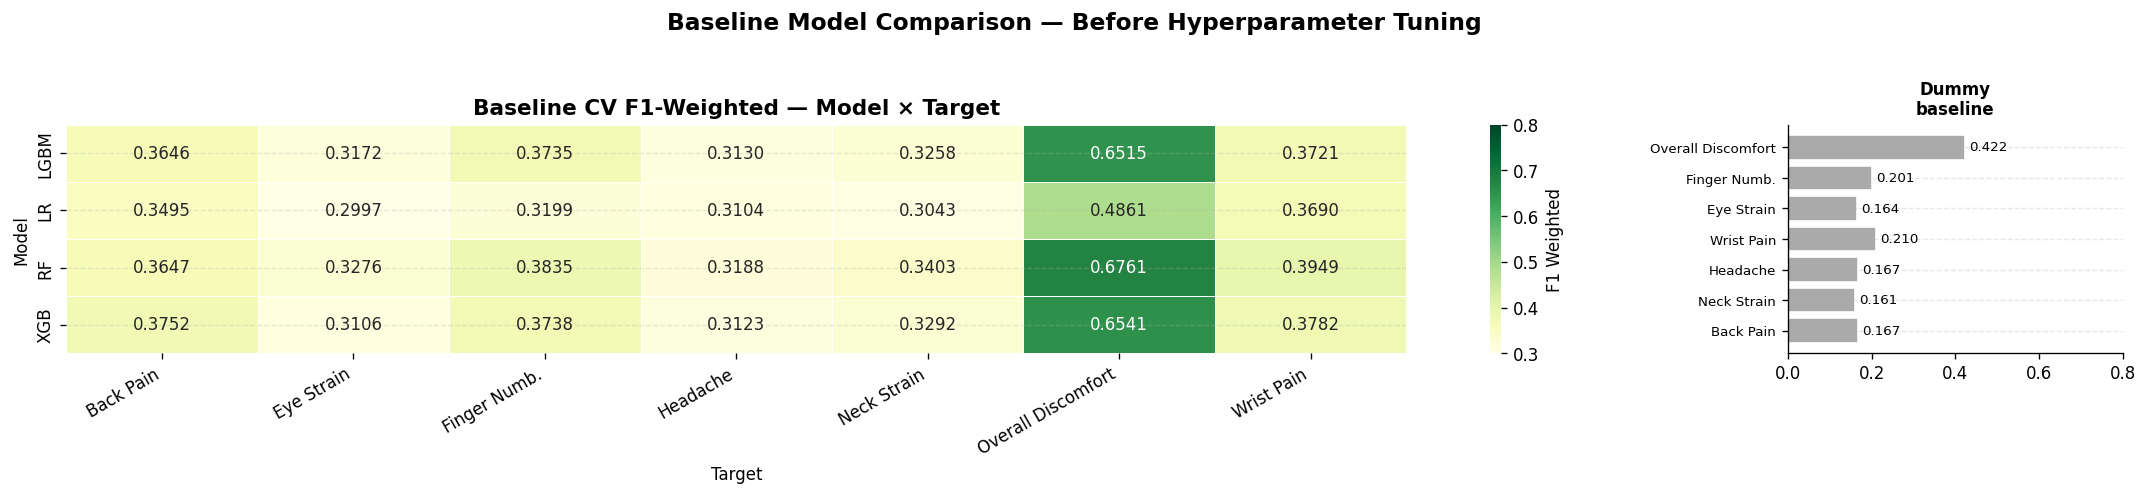

In [12]:
# ── Baseline heatmap: F1-weighted per model × target ─────────────────────────
pivot = baseline_df[baseline_df['Model'] != 'DUMMY'].pivot(
    index='Model', columns='Target', values='F1_Weighted'
)
dummy_row = baseline_df[baseline_df['Model'] == 'DUMMY'].set_index('Target')['F1_Weighted']

fig, axes = plt.subplots(1, 2, figsize=(18, 4),
                          gridspec_kw={'width_ratios': [5, 1]})

sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.3, vmax=0.8, linewidths=0.5,
            ax=axes[0], annot_kws={'size': 10},
            cbar_kws={'label': 'F1 Weighted'})
axes[0].set_title('Baseline CV F1-Weighted — Model × Target', fontweight='bold', fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylabel('Model')

# Dummy reference bar
axes[1].barh(range(len(dummy_row)), dummy_row.values, color='#aaa', edgecolor='white')
axes[1].set_yticks(range(len(dummy_row)))
axes[1].set_yticklabels([TARGET_NICE[t] for t in TARGET_COLS], fontsize=8)
axes[1].set_title('Dummy\nbaseline', fontweight='bold', fontsize=10)
axes[1].set_xlim(0, 0.8)
for j, v in enumerate(dummy_row.values):
    axes[1].text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Baseline Model Comparison — Before Hyperparameter Tuning',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [13]:
# ── Identify best baseline model per target ───────────────────────────────────
best_baseline = {}
for t in TARGET_COLS:
    scores = {m: r['f1_weighted'] for m, r in baseline_results[t].items() if m != 'DUMMY'}
    best_m = max(scores, key=scores.get)
    best_baseline[t] = best_m
    print(f"  {TARGET_NICE[t]:22s}  best baseline → {best_m}  (F1_wt={scores[best_m]:.4f})")


  Back Pain               best baseline → XGB  (F1_wt=0.3752)
  Neck Strain             best baseline → RF  (F1_wt=0.3403)
  Headache                best baseline → RF  (F1_wt=0.3188)
  Wrist Pain              best baseline → RF  (F1_wt=0.3949)
  Eye Strain              best baseline → RF  (F1_wt=0.3276)
  Finger Numb.            best baseline → RF  (F1_wt=0.3835)
  Overall Discomfort      best baseline → RF  (F1_wt=0.6761)


## 4. Hyperparameter Tuning

We tune the **top 2 models per target** (from baseline ranking) using  
`RandomizedSearchCV` with **Stratified 5-Fold CV** optimising for `f1_weighted`.  
Search budgets are kept practical (n_iter=30) given dataset size.


In [14]:
param_grids = {
    'LR': {
        'clf__C':       [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
        'clf__penalty': ['l2'],
        'clf__solver':  ['lbfgs', 'saga'],
    },
    'RF': {
        'n_estimators':      [200, 300, 500],
        'max_depth':         [None, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 3, 5],
        'max_features':      ['sqrt', 'log2', 0.5],
    },
    'XGB': {
        'n_estimators':     [200, 300, 500],
        'max_depth':        [3, 4, 5, 6, 8],
        'learning_rate':    [0.01, 0.05, 0.1, 0.15, 0.2],
        'subsample':        [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
        'gamma':            [0, 0.1, 0.3, 0.5],
        'reg_alpha':        [0, 0.1, 0.5, 1.0],
        'reg_lambda':       [1.0, 1.5, 2.0],
    },
    'LGBM': {
        'n_estimators':     [200, 300, 500],
        'max_depth':        [4, 6, 8, -1],
        'learning_rate':    [0.01, 0.05, 0.1, 0.15, 0.2],
        'num_leaves':       [31, 63, 127, 255],
        'subsample':        [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
        'reg_alpha':        [0, 0.1, 0.5, 1.0],
        'min_child_samples':[10, 20, 30],
    },
}
N_ITER = 50   # GPU makes this affordable

print(f"Parameter search spaces (n_iter={N_ITER} per model per target):")
for m, g in param_grids.items():
    combos = 1
    for v in g.values(): combos *= len(v)
    print(f"  {m:6s}: {len(g)} params · {combos:,} combinations · sampling {N_ITER}")


Parameter search spaces (n_iter=50 per model per target):
  LR    : 3 params · 16 combinations · sampling 50
  RF    : 5 params · 324 combinations · sampling 50
  XGB   : 8 params · 57,600 combinations · sampling 50
  LGBM  : 8 params · 46,080 combinations · sampling 50


In [15]:
tuned_models  = {}
tuning_scores = {}

print(f"Tuning with RandomizedSearchCV (n_iter={N_ITER}, cv={CV_FOLDS}-fold, f1_weighted) ...")
print("=" * 65)

for t in TARGET_COLS:
    tuned_models[t]  = {}
    tuning_scores[t] = {}
    y = df[t].values

    # Tune top 3 baseline models per target
    ranked = sorted(
        [(m, baseline_results[t][m]['f1_weighted']) for m in models_no_dummy],
        key=lambda x: x[1], reverse=True
    )
    top3 = [r[0] for r in ranked[:3]]
    print(f"\n  {TARGET_NICE[t]} — tuning: {top3}")

    for model_name in top3:
        pipes = make_pipelines()
        est   = pipes[model_name]
        grid  = param_grids.get(model_name, {})

        if not grid:
            est.fit(splits[t]['X_train'], splits[t]['y_train'])
            tuned_models[t][model_name]  = est
            tuning_scores[t][model_name] = baseline_results[t][model_name]['f1_weighted']
            print(f"    {model_name}: no grid  F1={tuning_scores[t][model_name]:.4f}")
            continue

        search = RandomizedSearchCV(
            est, grid, n_iter=N_ITER,
            cv=skf, scoring='f1_weighted',
            n_jobs=1,                     # 1 job — parallelism is inside GPU kernels
            random_state=RANDOM_STATE,
            refit=True, verbose=1
        )
        search.fit(X, y)
        tuned_models[t][model_name]  = search.best_estimator_
        tuning_scores[t][model_name] = search.best_score_
        print(f"    {model_name}: F1_wt={search.best_score_:.4f}  "
              f"best_params={search.best_params_}")

print("\n✓ Tuning complete.")


Tuning with RandomizedSearchCV (n_iter=50, cv=5-fold, f1_weighted) ...

  Back Pain — tuning: ['XGB', 'RF', 'LGBM']
Fitting 5 folds for each of 50 candidates, totalling 250 fits
    XGB: F1_wt=0.3838  best_params={'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 50 candidates, totalling 250 fits
    RF: F1_wt=0.3837  best_params={'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': None}
Fitting 5 folds for each of 50 candidates, totalling 250 fits
    LGBM: F1_wt=0.3799  best_params={'subsample': 1.0, 'reg_alpha': 0, 'num_leaves': 255, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

  Neck Strain — tuning: ['RF', 'XGB', 'LGBM']
Fitting 5 folds for each of 50 candidates, totalling 250 fits
    RF: F1_wt=0.3648  best_params={'n_estimators': 50

---
### 🔁 Results Export Cell
Run this cell after tuning completes. It saves all results needed for the analysis  
sections (5–7). **Share the `phase4_exports/` folder and `models/` folder back.**  
You can delete this cell once the analysis sections are populated.

---


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  RESULTS EXPORT — run after tuning, send outputs back for analysis     ║
# ║  You can remove this cell once you have shared the exported files.     ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import json, pickle, os
os.makedirs('models', exist_ok=True)
os.makedirs('phase4_exports', exist_ok=True)

# ── 1. Save all tuned model objects ──────────────────────────────────────────
for t, models_dict in tuned_models.items():
    for model_name, est in models_dict.items():
        path = f"models/{t}_{model_name}.pkl"
        with open(path, 'wb') as f:
            pickle.dump(est, f)
print(f"✓ Tuned models saved to models/")

# ── 2. Export tuning scores (CV F1 per model per target) ─────────────────────
tuning_export = {
    t: {m: round(s, 6) for m, s in scores.items()}
    for t, scores in tuning_scores.items()
}
with open('phase4_exports/tuning_scores.json', 'w') as f:
    json.dump(tuning_export, f, indent=2)
print("✓ Saved phase4_exports/tuning_scores.json")

# ── 3. Export baseline results ────────────────────────────────────────────────
baseline_export = {
    t: {m: {k: round(v, 6) for k, v in r.items()}
        for m, r in res.items()}
    for t, res in baseline_results.items()
}
with open('phase4_exports/baseline_results.json', 'w') as f:
    json.dump(baseline_export, f, indent=2)
print("✓ Saved phase4_exports/baseline_results.json")

# ── 4. Export best model name per target ─────────────────────────────────────
best_model_names = {
    t: max(tuning_scores[t], key=tuning_scores[t].get)
    for t in TARGET_COLS
}
with open('phase4_exports/best_model_names.json', 'w') as f:
    json.dump(best_model_names, f, indent=2)
print("✓ Saved phase4_exports/best_model_names.json")

# ── 5. Export test-set predictions & metrics ──────────────────────────────────
# (generated in section 5 — run this cell again after section 5 if needed)
if 'test_results' in vars():
    pred_export = {}
    for t in TARGET_COLS:
        r = test_results[t]
        pred_export[t] = {
            'best_model':   r['best_model'],
            'cv_f1_wt':     r['cv_f1_wt'],
            'test_f1_wt':   r['test_f1_wt'],
            'test_f1_mac':  r['test_f1_mac'],
            'test_acc':     r['test_acc'],
            'y_test':       r['y_test'].tolist(),
            'y_pred':       r['y_pred'].tolist(),
            'classification_report': all_reports[t],
        }
    with open('phase4_exports/test_predictions.json', 'w') as f:
        json.dump(pred_export, f, indent=2)
    print("✓ Saved phase4_exports/test_predictions.json")

# ── 6. Export CV summary ──────────────────────────────────────────────────────
if 'cv_summary' in vars():
    cv_export = {
        t: {k: (v if not hasattr(v, 'tolist') else v) for k, v in s.items()}
        for t, s in cv_summary.items()
    }
    with open('phase4_exports/cv_summary.json', 'w') as f:
        json.dump(cv_export, f, indent=2)
    print("✓ Saved phase4_exports/cv_summary.json")

print("\n=== FILES TO SEND BACK ===")
for root, dirs, files in os.walk('phase4_exports'):
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        print(f"  {fpath}  ({os.path.getsize(fpath)//1024 + 1} KB)")
for root, dirs, files in os.walk('models'):
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        print(f"  {fpath}  ({os.path.getsize(fpath)//1024 + 1} KB)")


✓ Tuned models saved to models/
✓ Saved phase4_exports/tuning_scores.json
✓ Saved phase4_exports/baseline_results.json
✓ Saved phase4_exports/best_model_names.json

=== FILES TO SEND BACK ===
  phase4_exports\baseline_results.json  (5 KB)
  phase4_exports\best_model_names.json  (1 KB)
  phase4_exports\tuning_scores.json  (1 KB)
  models\target_back_pain_LGBM.pkl  (6688 KB)
  models\target_back_pain_RF.pkl  (4324 KB)
  models\target_back_pain_XGB.pkl  (2534 KB)
  models\target_eye_strain_LGBM.pkl  (3609 KB)
  models\target_eye_strain_RF.pkl  (4946 KB)
  models\target_eye_strain_XGB.pkl  (1255 KB)
  models\target_finger_numb_LGBM.pkl  (2948 KB)
  models\target_finger_numb_RF.pkl  (6492 KB)
  models\target_finger_numb_XGB.pkl  (6759 KB)
  models\target_headache_LGBM.pkl  (2181 KB)
  models\target_headache_LR.pkl  (3 KB)
  models\target_headache_RF.pkl  (9143 KB)
  models\target_headache_XGB.pkl  (1983 KB)
  models\target_neck_strain_LGBM.pkl  (2061 KB)
  models\target_neck_strain_RF.pkl  

## 5. Best Model Selection per Target

The tuned model with the highest **cross-validated weighted F1** is selected per target.  
It is then re-fitted on the full training set and evaluated on the held-out test set.


In [17]:
best_models     = {}   # {target: fitted_estimator}
test_results    = {}   # {target: dict of metrics}
all_reports     = {}   # {target: classification_report string}

print(f"{'Target':22s}  {'Best Model':6s}  {'CV F1_wt':9s}  {'Test F1_wt':10s}  "
      f"{'Test F1_mac':11s}  {'Test Acc':9s}")
print("-" * 75)

for t in TARGET_COLS:
    # Pick best tuned model
    best_name = max(tuning_scores[t], key=tuning_scores[t].get)
    best_est  = tuned_models[t][best_name]

    X_tr, X_te = splits[t]['X_train'], splits[t]['X_test']
    y_tr, y_te = splits[t]['y_train'], splits[t]['y_test']

    # Refit on full training set
    best_est.fit(X_tr, y_tr)
    y_pred = best_est.predict(X_te)

    f1_wt  = f1_score(y_te, y_pred, average='weighted')
    f1_mac = f1_score(y_te, y_pred, average='macro')
    acc    = accuracy_score(y_te, y_pred)
    cv_f1  = tuning_scores[t][best_name]

    best_models[t]  = best_est
    test_results[t] = {
        'best_model':  best_name,
        'cv_f1_wt':    round(cv_f1,  4),
        'test_f1_wt':  round(f1_wt,  4),
        'test_f1_mac': round(f1_mac, 4),
        'test_acc':    round(acc,    4),
        'y_test':      y_te,
        'y_pred':      y_pred,
    }
    all_reports[t] = classification_report(y_te, y_pred,
        target_names=['None','Mild','Moderate','Chronic'])

    print(f"  {TARGET_NICE[t]:22s}  {best_name:6s}  {cv_f1:.4f}     {f1_wt:.4f}      "
          f"{f1_mac:.4f}       {acc:.4f}")


Target                  Best Model  CV F1_wt   Test F1_wt  Test F1_mac  Test Acc 
---------------------------------------------------------------------------
  Back Pain               XGB     0.3838     0.3927      0.3172       0.4188
  Neck Strain             RF      0.3648     0.3374      0.3182       0.3419
  Headache                XGB     0.3338     0.2998      0.2685       0.3120
  Wrist Pain              RF      0.4109     0.3806      0.3087       0.4017
  Eye Strain              RF      0.3446     0.3345      0.3183       0.3376
  Finger Numb.            LGBM    0.3891     0.3704      0.3199       0.3761
  Overall Discomfort      RF      0.6838     0.6685      0.4496       0.6795


In [18]:
# ── Detailed classification reports ──────────────────────────────────────────
print("=== CLASSIFICATION REPORTS (test set) ===\n")
for t in TARGET_COLS:
    res = test_results[t]
    print(f"{'─'*60}")
    print(f"  {TARGET_NICE[t]}  |  Model: {res['best_model']}  "
          f"|  CV F1_wt={res['cv_f1_wt']}  |  Test F1_wt={res['test_f1_wt']}")
    print(f"{'─'*60}")
    print(all_reports[t])


=== CLASSIFICATION REPORTS (test set) ===

────────────────────────────────────────────────────────────
  Back Pain  |  Model: XGB  |  CV F1_wt=0.3838  |  Test F1_wt=0.3927
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        None       0.00      0.00      0.00        20
        Mild       0.35      0.38      0.36        64
    Moderate       0.36      0.32      0.34        72
     Chronic       0.50      0.65      0.57        78

    accuracy                           0.42       234
   macro avg       0.30      0.34      0.32       234
weighted avg       0.37      0.42      0.39       234

────────────────────────────────────────────────────────────
  Neck Strain  |  Model: RF  |  CV F1_wt=0.3648  |  Test F1_wt=0.3374
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        None       0.24      0.15      0.19        33
        Mild       0.33      0

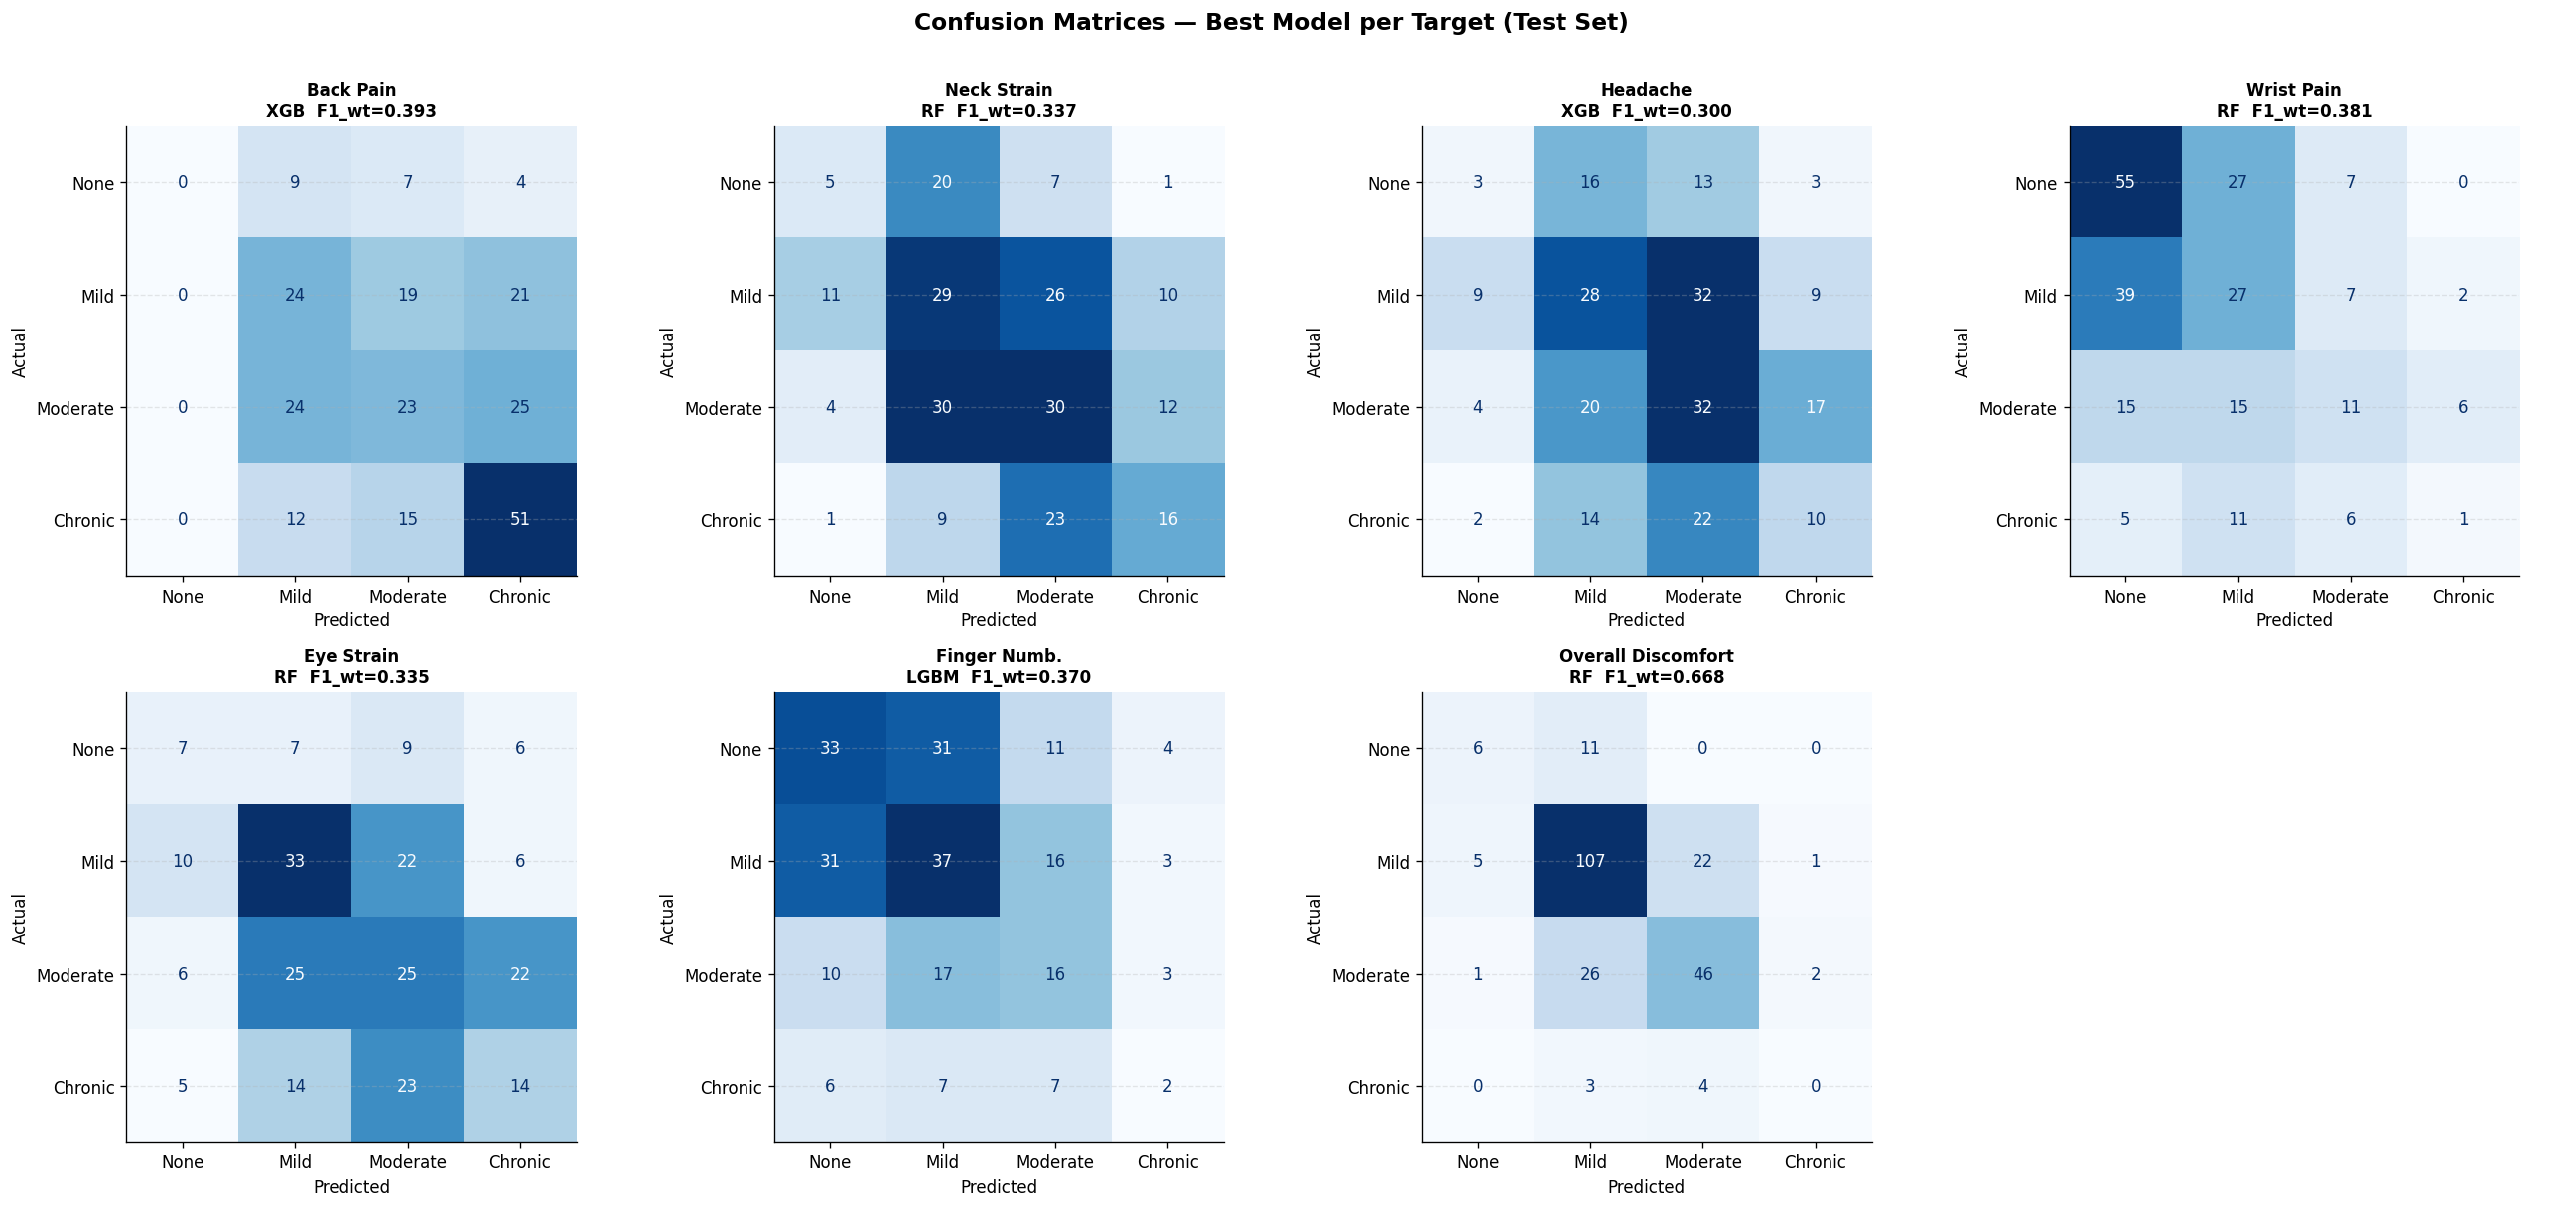

In [19]:
# ── Confusion matrices — all 7 targets ───────────────────────────────────────
CLASS_NAMES = ['None','Mild','Moderate','Chronic']
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax = axes[i]
    cm = confusion_matrix(test_results[t]['y_test'], test_results[t]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f"{TARGET_NICE[t]}\n{test_results[t]['best_model']}  "
        f"F1_wt={test_results[t]['test_f1_wt']:.3f}",
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — Best Model per Target (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 6. Cross-Validated Performance Summary

In [20]:
# ── Full CV with best tuned models ───────────────────────────────────────────
cv_summary = {}
print("Running final CV on best tuned models ...")
for t in TARGET_COLS:
    best_est = best_models[t]
    y_full   = df[t].values
    cv_res   = cross_validate(
        best_est, X, y_full,
        cv=skf,
        scoring=['f1_weighted','f1_macro','accuracy'],
        n_jobs=-1
    )
    cv_summary[t] = {
        'model':      test_results[t]['best_model'],
        'f1_wt_mean': cv_res['test_f1_weighted'].mean(),
        'f1_wt_std':  cv_res['test_f1_weighted'].std(),
        'f1_mac_mean':cv_res['test_f1_macro'].mean(),
        'f1_mac_std': cv_res['test_f1_macro'].std(),
        'acc_mean':   cv_res['test_accuracy'].mean(),
        'acc_std':    cv_res['test_accuracy'].std(),
        'fold_scores':cv_res['test_f1_weighted'].tolist(),
    }
    print(f"  {TARGET_NICE[t]:22s}  {test_results[t]['best_model']:6s}  "
          f"F1_wt={cv_res['test_f1_weighted'].mean():.4f} ± {cv_res['test_f1_weighted'].std():.4f}")


Running final CV on best tuned models ...
  Back Pain               XGB     F1_wt=0.3838 ± 0.0103
  Neck Strain             RF      F1_wt=0.3648 ± 0.0407
  Headache                XGB     F1_wt=0.3338 ± 0.0167
  Wrist Pain              RF      F1_wt=0.4109 ± 0.0087
  Eye Strain              RF      F1_wt=0.3446 ± 0.0230
  Finger Numb.            LGBM    F1_wt=0.3891 ± 0.0235
  Overall Discomfort      RF      F1_wt=0.6838 ± 0.0241


In [21]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = []
for t in TARGET_COLS:
    s = cv_summary[t]
    summary_rows.append({
        'Target':        TARGET_NICE[t],
        'Best Model':    s['model'],
        'CV F1_wt':      f"{s['f1_wt_mean']:.4f} ± {s['f1_wt_std']:.4f}",
        'CV F1_mac':     f"{s['f1_mac_mean']:.4f} ± {s['f1_mac_std']:.4f}",
        'CV Accuracy':   f"{s['acc_mean']:.4f} ± {s['acc_std']:.4f}",
        'Test F1_wt':    test_results[t]['test_f1_wt'],
        'Test F1_mac':   test_results[t]['test_f1_mac'],
        'Test Acc':      test_results[t]['test_acc'],
    })

summary_df = pd.DataFrame(summary_rows)
print("=== FINAL MODEL PERFORMANCE SUMMARY ===")
print(summary_df.to_string(index=False))


=== FINAL MODEL PERFORMANCE SUMMARY ===
            Target Best Model        CV F1_wt       CV F1_mac     CV Accuracy  Test F1_wt  Test F1_mac  Test Acc
         Back Pain        XGB 0.3838 ± 0.0103 0.3146 ± 0.0131 0.4051 ± 0.0087      0.3927       0.3172    0.4188
       Neck Strain         RF 0.3648 ± 0.0407 0.3330 ± 0.0323 0.3769 ± 0.0462      0.3374       0.3182    0.3419
          Headache        XGB 0.3338 ± 0.0167 0.3111 ± 0.0202 0.3419 ± 0.0160      0.2998       0.2685    0.3120
        Wrist Pain         RF 0.4109 ± 0.0087 0.3558 ± 0.0149 0.4256 ± 0.0139      0.3806       0.3087    0.4017
        Eye Strain         RF 0.3446 ± 0.0230 0.3200 ± 0.0233 0.3479 ± 0.0233      0.3345       0.3183    0.3376
      Finger Numb.       LGBM 0.3891 ± 0.0235 0.3438 ± 0.0319 0.3949 ± 0.0247      0.3704       0.3199    0.3761
Overall Discomfort         RF 0.6838 ± 0.0241 0.4935 ± 0.0382 0.6915 ± 0.0236      0.6685       0.4496    0.6795


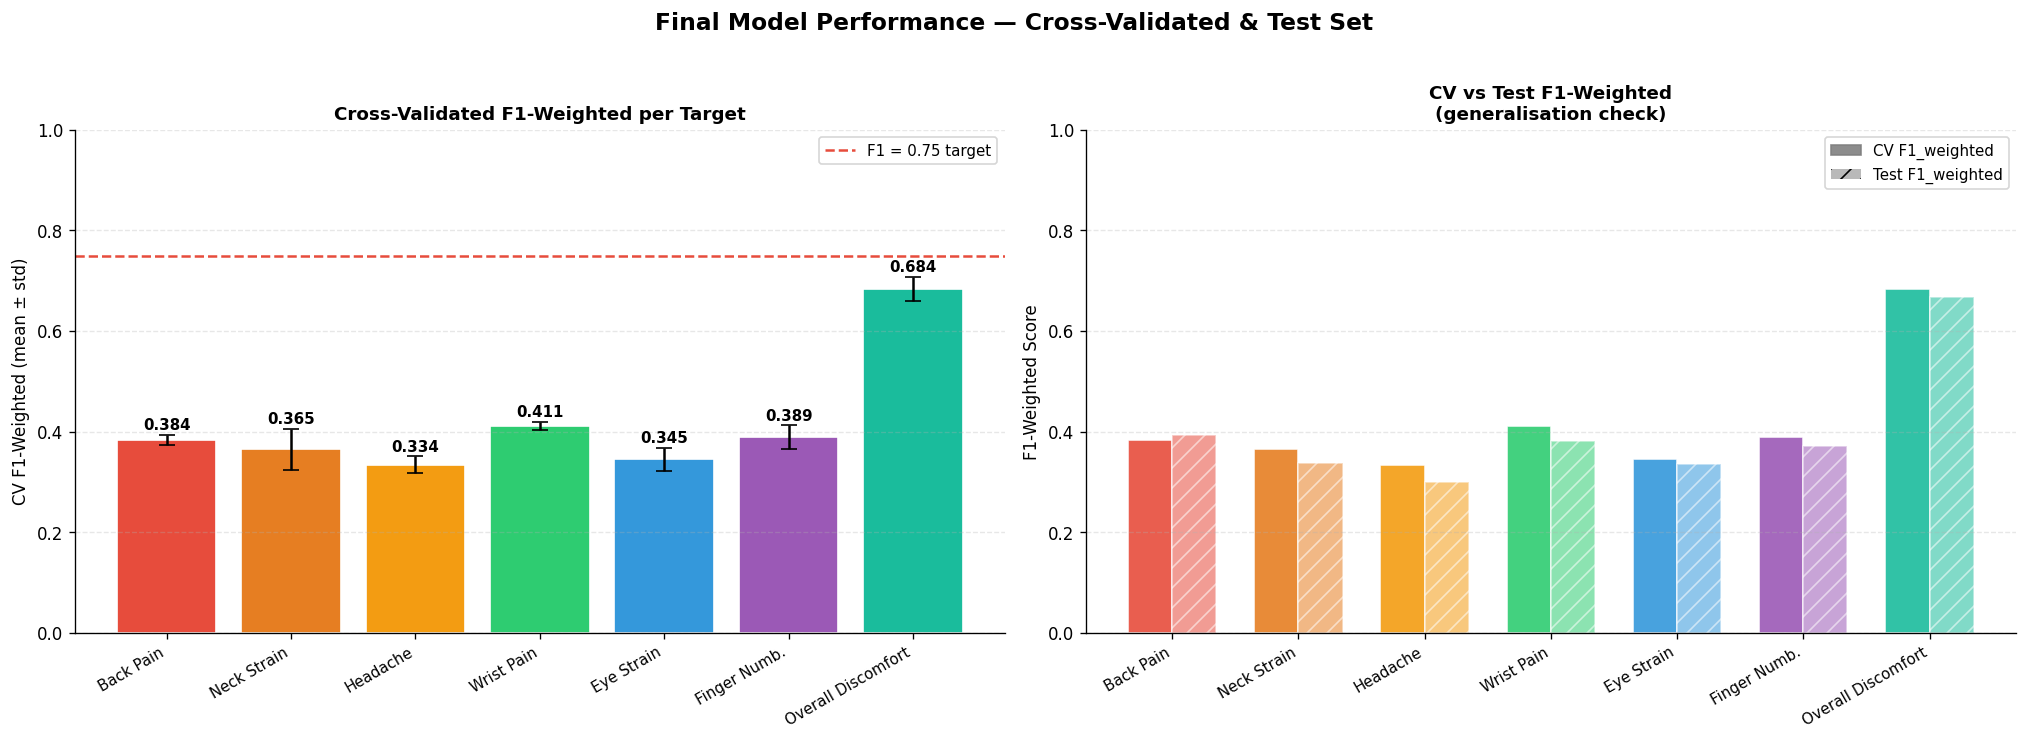

In [22]:
# ── Performance comparison bar chart ─────────────────────────────────────────
targets_nice = [TARGET_NICE[t] for t in TARGET_COLS]
f1_wt_means  = [cv_summary[t]['f1_wt_mean']  for t in TARGET_COLS]
f1_wt_stds   = [cv_summary[t]['f1_wt_std']   for t in TARGET_COLS]
f1_mac_means = [cv_summary[t]['f1_mac_mean'] for t in TARGET_COLS]
test_f1s     = [test_results[t]['test_f1_wt'] for t in TARGET_COLS]
bar_colors   = [TARGET_COLORS[t] for t in TARGET_COLS]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# CV F1 weighted with error bars
x = np.arange(len(TARGET_COLS))
bars = axes[0].bar(x, f1_wt_means, yerr=f1_wt_stds,
                   color=bar_colors, edgecolor='white',
                   capsize=5, error_kw={'lw': 1.5})
axes[0].axhline(0.75, color='#e74c3c', lw=1.5, linestyle='--', label='F1 = 0.75 target')
axes[0].set_xticks(x)
axes[0].set_xticklabels(targets_nice, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('CV F1-Weighted (mean ± std)')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Cross-Validated F1-Weighted per Target', fontweight='bold')
axes[0].legend(fontsize=9)
for bar, v, s in zip(bars, f1_wt_means, f1_wt_stds):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+s+0.01,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# CV vs Test F1 comparison
w = 0.35
axes[1].bar(x - w/2, f1_wt_means, width=w, color=bar_colors,
            edgecolor='white', label='CV F1_wt', alpha=0.9)
axes[1].bar(x + w/2, test_f1s,    width=w, color=bar_colors,
            edgecolor='white', label='Test F1_wt', alpha=0.55, hatch='//')
axes[1].set_xticks(x)
axes[1].set_xticklabels(targets_nice, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('F1-Weighted Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_title('CV vs Test F1-Weighted\n(generalisation check)', fontweight='bold')
solid_patch = mpatches.Patch(color='grey', alpha=0.9, label='CV F1_weighted')
hatch_patch = mpatches.Patch(facecolor='grey', alpha=0.55, hatch='//', label='Test F1_weighted')
axes[1].legend(handles=[solid_patch, hatch_patch], fontsize=9)

plt.suptitle('Final Model Performance — Cross-Validated & Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


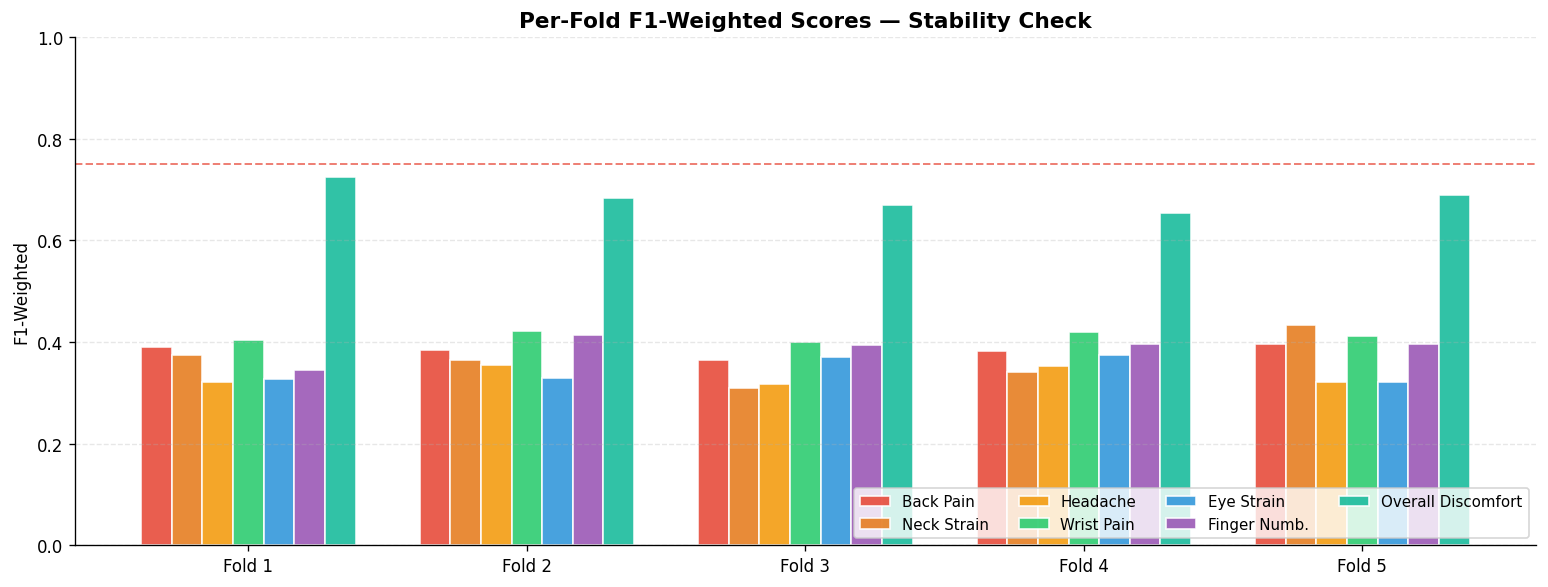

In [23]:
# ── Per-fold F1 scores — variance across folds ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
w = 0.11
x = np.arange(CV_FOLDS)

for i, t in enumerate(TARGET_COLS):
    fold_scores = cv_summary[t]['fold_scores']
    offset = (i - 3) * w
    ax.bar(x + offset, fold_scores, width=w,
           color=TARGET_COLORS[t], edgecolor='white',
           alpha=0.9, label=TARGET_NICE[t])

ax.set_xticks(range(CV_FOLDS))
ax.set_xticklabels([f'Fold {i+1}' for i in range(CV_FOLDS)])
ax.set_ylabel('F1-Weighted')
ax.set_ylim(0, 1.0)
ax.set_title('Per-Fold F1-Weighted Scores — Stability Check', fontweight='bold', fontsize=13)
ax.legend(ncol=4, fontsize=9, loc='lower right')
ax.axhline(0.75, color='#e74c3c', lw=1.2, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


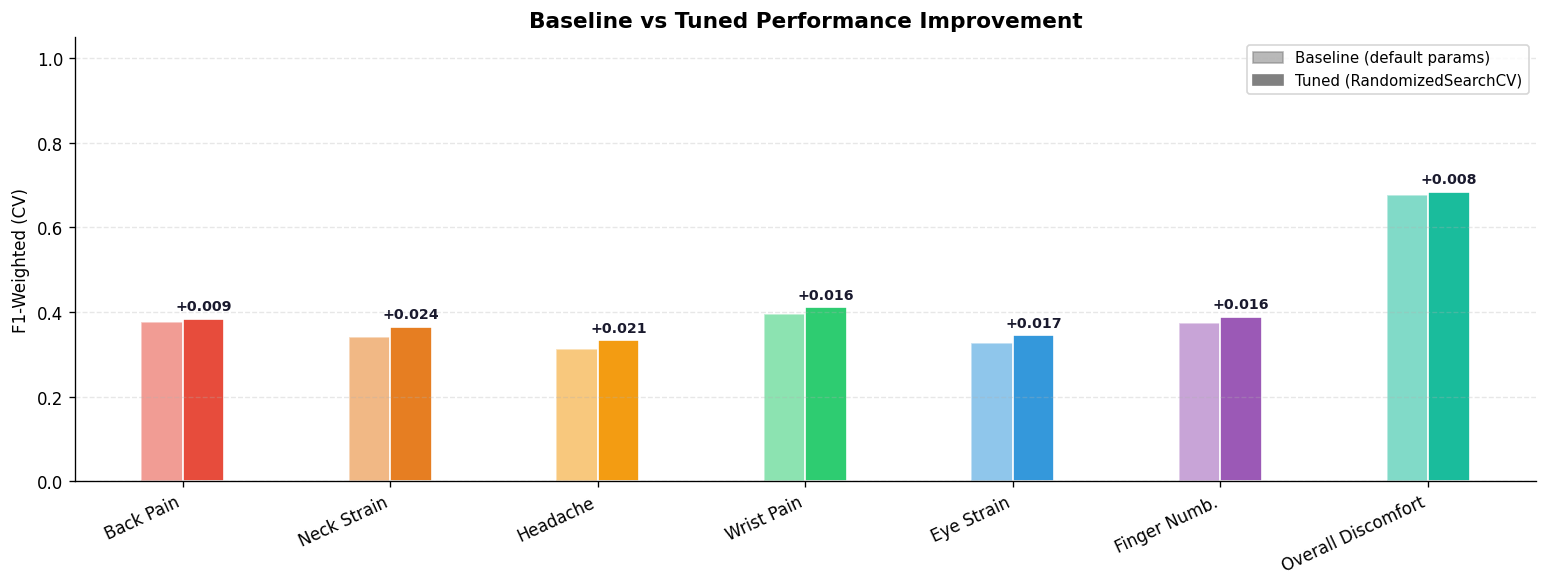

In [24]:
# ── Baseline vs tuned improvement ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
w = 0.2

for i, t in enumerate(TARGET_COLS):
    best_m    = test_results[t]['best_model']
    base_f1   = baseline_results[t][best_m]['f1_weighted']
    tuned_f1  = cv_summary[t]['f1_wt_mean']
    x_pos     = i
    ax.bar(x_pos - w/2, base_f1,  width=w, color=TARGET_COLORS[t],
           edgecolor='white', alpha=0.55, label='_nolegend_')
    ax.bar(x_pos + w/2, tuned_f1, width=w, color=TARGET_COLORS[t],
           edgecolor='white', alpha=1.0,  label='_nolegend_')
    gain = tuned_f1 - base_f1
    ax.annotate(f'+{gain:.3f}',
                xy=(x_pos + w/2, tuned_f1),
                xytext=(x_pos + w/2, tuned_f1 + 0.02),
                ha='center', fontsize=8.5, color='#1a1a2e', fontweight='bold')

ax.set_xticks(range(len(TARGET_COLS)))
ax.set_xticklabels([TARGET_NICE[t] for t in TARGET_COLS], rotation=25, ha='right')
ax.set_ylabel('F1-Weighted (CV)')
ax.set_ylim(0, 1.05)
ax.set_title('Baseline vs Tuned Performance Improvement', fontweight='bold', fontsize=13)
pale   = mpatches.Patch(color='grey', alpha=0.55, label='Baseline (default params)')
solid  = mpatches.Patch(color='grey', alpha=1.0,  label='Tuned (RandomizedSearchCV)')
ax.legend(handles=[pale, solid], fontsize=9)
plt.tight_layout()
plt.show()


## 7. Learning Curves

Learning curves show how model performance evolves as training size increases.  
They reveal **underfitting** (both curves low) or **overfitting** (large train/val gap).


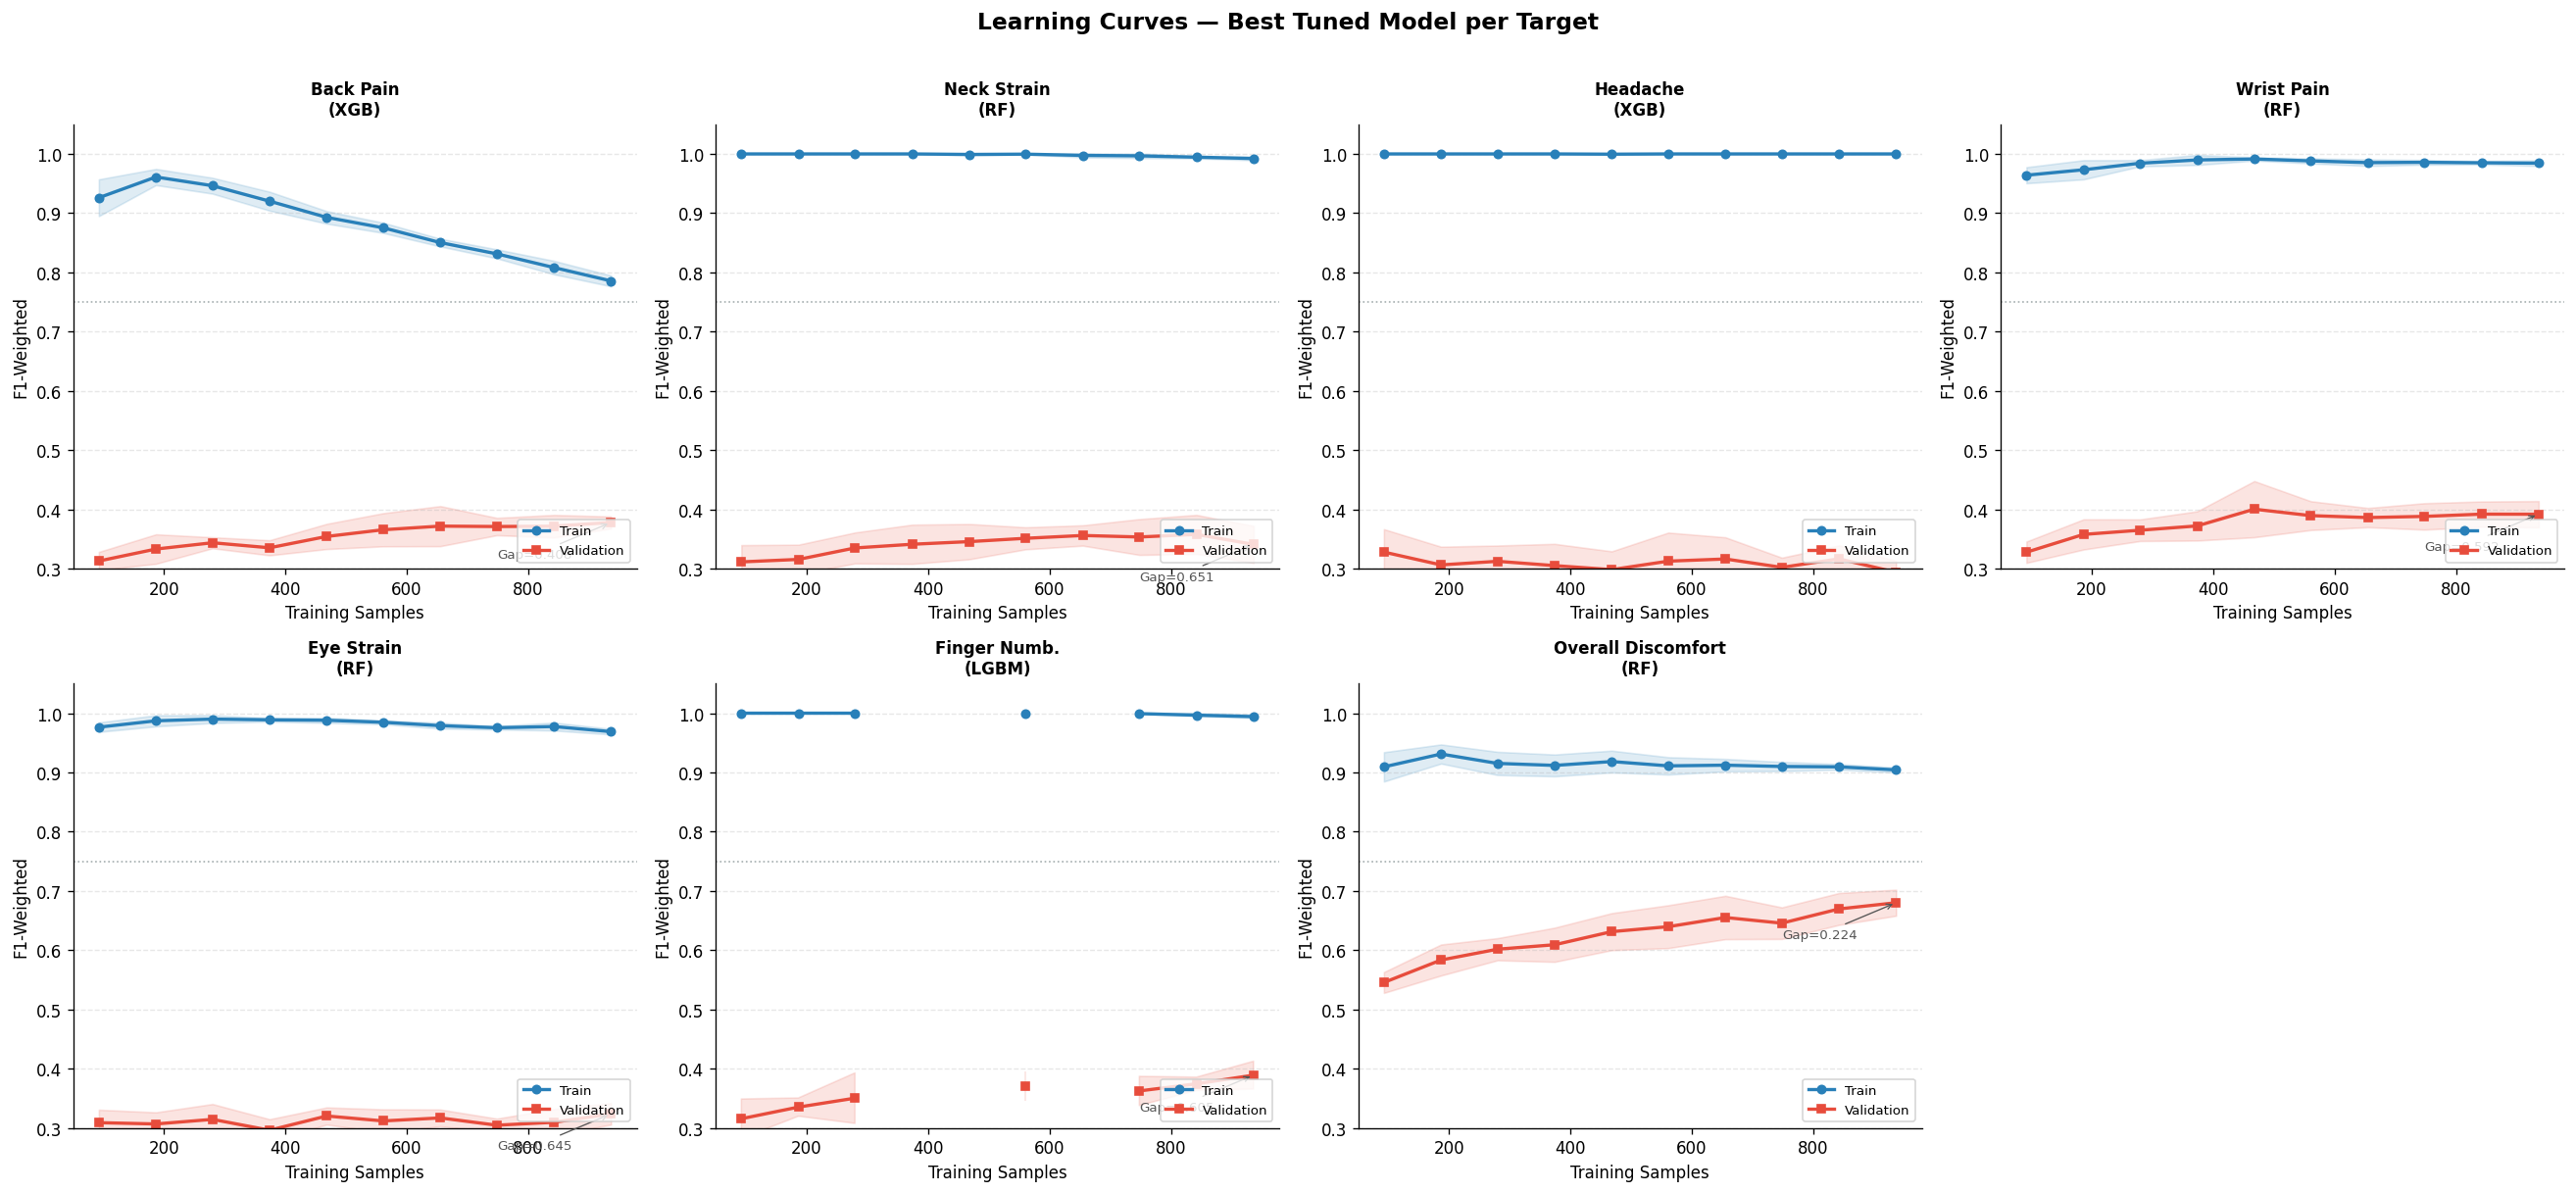

In [25]:
TRAIN_SIZES = np.linspace(0.10, 1.0, 10)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, t in enumerate(TARGET_COLS):
    ax = axes[i]
    best_est = best_models[t]
    y_full   = df[t].values

    train_sizes_abs, train_scores, val_scores = learning_curve(
        best_est, X, y_full,
        train_sizes=TRAIN_SIZES,
        cv=skf, scoring='f1_weighted',
        n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_mean = val_scores.mean(axis=1)
    va_std  = val_scores.std(axis=1)

    ax.fill_between(train_sizes_abs, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#2980b9')
    ax.fill_between(train_sizes_abs, va_mean-va_std, va_mean+va_std, alpha=0.15, color='#e74c3c')
    ax.plot(train_sizes_abs, tr_mean, 'o-', color='#2980b9', lw=2, ms=5, label='Train')
    ax.plot(train_sizes_abs, va_mean, 's-', color='#e74c3c', lw=2, ms=5, label='Validation')
    ax.axhline(0.75, color='#7f8c8d', lw=1, linestyle=':', alpha=0.7)
    ax.set_title(f"{TARGET_NICE[t]}\n({test_results[t]['best_model']})", fontweight='bold', fontsize=10)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1-Weighted')
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=8, loc='lower right')

    # Annotate final gap
    gap = tr_mean[-1] - va_mean[-1]
    ax.annotate(f'Gap={gap:.3f}', xy=(train_sizes_abs[-1], va_mean[-1]),
                xytext=(train_sizes_abs[-3], va_mean[-1]-0.06),
                fontsize=8, color='#555',
                arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))

axes[-1].axis('off')
plt.suptitle('Learning Curves — Best Tuned Model per Target',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 8. Export — Trained Models & Results

In [26]:
os.makedirs('models', exist_ok=True)

# Save each best model
for t, model in best_models.items():
    path = f"models/{t}_best_model.pkl"
    with open(path, 'wb') as f:
        pickle.dump(model, f)
print(f"✓ Saved {len(best_models)} trained models to models/")

# Build & save results summary
results_export = {}
for t in TARGET_COLS:
    results_export[t] = {
        'best_model':   test_results[t]['best_model'],
        'cv_f1_wt':     cv_summary[t]['f1_wt_mean'],
        'cv_f1_wt_std': cv_summary[t]['f1_wt_std'],
        'cv_f1_mac':    cv_summary[t]['f1_mac_mean'],
        'cv_accuracy':  cv_summary[t]['acc_mean'],
        'test_f1_wt':   test_results[t]['test_f1_wt'],
        'test_f1_mac':  test_results[t]['test_f1_mac'],
        'test_acc':     test_results[t]['test_acc'],
        'fold_scores':  cv_summary[t]['fold_scores'],
        'classification_report': all_reports[t],
    }

with open('phase4_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)
print("✓ Saved phase4_results.json")

# Baseline results
baseline_export = {
    t: {m: {k: v for k, v in r.items()} for m, r in baseline_results[t].items()}
    for t in TARGET_COLS
}
with open('phase4_baseline_results.json', 'w') as f:
    json.dump(baseline_export, f, indent=2)
print("✓ Saved phase4_baseline_results.json")

# Summary table CSV
summary_df.to_csv('phase4_model_summary.csv', index=False)
print("✓ Saved phase4_model_summary.csv")

print(f"\n{'='*60}")
print(f"  PHASE 4 COMPLETE")
print(f"{'='*60}")
for t in TARGET_COLS:
    r = results_export[t]
    print(f"  {TARGET_NICE[t]:22s}  {r['best_model']:6s}  "
          f"CV={r['cv_f1_wt']:.4f}±{r['cv_f1_wt_std']:.4f}  "
          f"Test={r['test_f1_wt']:.4f}")
print(f"{'='*60}")


✓ Saved 7 trained models to models/
✓ Saved phase4_results.json
✓ Saved phase4_baseline_results.json
✓ Saved phase4_model_summary.csv

  PHASE 4 COMPLETE
  Back Pain               XGB     CV=0.3838±0.0103  Test=0.3927
  Neck Strain             RF      CV=0.3648±0.0407  Test=0.3374
  Headache                XGB     CV=0.3338±0.0167  Test=0.2998
  Wrist Pain              RF      CV=0.4109±0.0087  Test=0.3806
  Eye Strain              RF      CV=0.3446±0.0230  Test=0.3345
  Finger Numb.            LGBM    CV=0.3891±0.0235  Test=0.3704
  Overall Discomfort      RF      CV=0.6838±0.0241  Test=0.6685
